# Accident Spatial Autocorrelation（L3）

把自行車事故點做 **H3 格化**，用空間自相關看「事故聚不聚集、熱點在哪、聚集尺度多大」。
**純觀察，不動風險模型**。

**方法**：H3 聚合（res 8/9 主力 + res 10 對照）→ 全域 Moran's I → LISA 局部熱點 → Incremental SA 找尺度。

**needs**：postgis 起著（`accidents` 表）。**scale L3**。依賴：`h3` / `libpysal` / `esda`。

**必記 caveat**：
- **暴露量缺失（核心限制）**：事故數多可能只是「騎的人多」，非「每人風險高」（無車流/騎乘量分母）。
  結果是 **accident hotspot，不是 exposure-adjusted risk**。有暴露量才能做 **dual KDE / relative risk surface**
  （事故密度 ÷ 暴露密度）逼近單位暴露風險；此限制同樣適用於 road_risk（皆為「事故在哪」，非「每人風險」）。
- **只用占用格**：本版只建**有事故**的 H3 cell → 是在「有事故的格之間」看事故數是否鄰近相似，
  非估計整個研究區（含零事故格）的完整分布。要更完整需先定義研究範圍 mask（道路 buffer / 行政區）再建含 0 的格。
- **MAUP（可變面積單元問題）**：結論隨解析度/格位置改變 → 標明「在此解析度下」、跨級檢查。
- 這是**描述性 / 合理性**分析，非嚴格校準（描述性 / 合理性分析）。

In [1]:
import os, warnings
warnings.filterwarnings("ignore", message="IProgress not found")  # esda 匯入 tqdm 的 cosmetic 警告
warnings.filterwarnings("ignore", category=RuntimeWarning, module="esda.moran")  # Moran_Local 內部 z_sim 除零（未使用 z_sim）
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
%matplotlib inline
for _f in ("Noto Sans CJK TC", "PingFang TC", "Microsoft JhengHei"):
    if any(_f == f.name for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.sans-serif"] = [_f]; break
plt.rcParams["axes.unicode_minus"] = False

import h3
from sqlalchemy import create_engine
from libpysal.weights import W
from esda.moran import Moran, Moran_Local
from app.config import settings

DB_URL = os.getenv("DATABASE_URL", settings.database_url)
eng = create_engine(DB_URL)

# 事故點：geom 為 EPSG:3857 → 轉 4326 拿 lat/lon 給 h3；帶 case_type / 死傷 算加權嚴重度
acc = pd.read_sql(
    "SELECT case_type, death_count, injury_count, "
    "       ST_Y(ST_Transform(geom,4326)) AS lat, ST_X(ST_Transform(geom,4326)) AS lon "
    "FROM accidents", eng)

# 加權嚴重度（沿用 settings 的 A1/A2 係數；此處不加時間衰減，屬 v1 簡化）
w1d, w1i = settings.RISK_A1_DEATH_WEIGHT, settings.RISK_A1_INJURY_WEIGHT
w2d, w2i = settings.RISK_A2_DEATH_WEIGHT, settings.RISK_A2_INJURY_WEIGHT
is_a1 = acc["case_type"].astype(str).str.upper().eq("A1")
acc["severity"] = np.where(is_a1,
    acc.death_count*w1d + acc.injury_count*w1i,
    acc.death_count*w2d + acc.injury_count*w2i)
print(f"事故 {len(acc):,} 筆；A1 {int(is_a1.sum()):,} / A2 {int((~is_a1).sum()):,}")
acc[["case_type","death_count","injury_count","severity"]].head()

事故 60,953 筆；A1 370 / A2 60,583


,case_type,death_count,injury_count,severity
0,A1,1,0,3.0
1,A1,1,0,3.0
2,A1,1,1,4.5
3,A1,1,0,3.0
4,A1,2,2,9.0


## 1. H3 聚合（res 8 / 9 主力 + res 10 對照）

每筆事故指派到 H3 cell，每格聚合「事故數」與「加權嚴重度」（沿用 A1/A2 死傷權重，**v1 不含時間衰減**——
本本定位是空間結構觀察，非完整 risk model 重算）。**印各解析度的占用格計數分佈**——
用真實數字驗證「res-10 是否多數格只有 1 件、太稀疏」。

res  8（邊長~  531m）：占用格  8,863｜=1 件  3,222 ( 36%)｜最大  263｜中位 2
res  9（邊長~  201m）：占用格 21,861｜=1 件 10,754 ( 49%)｜最大  214｜中位 2
res 10（邊長~   76m）：占用格 39,545｜=1 件 27,823 ( 70%)｜最大  209｜中位 1


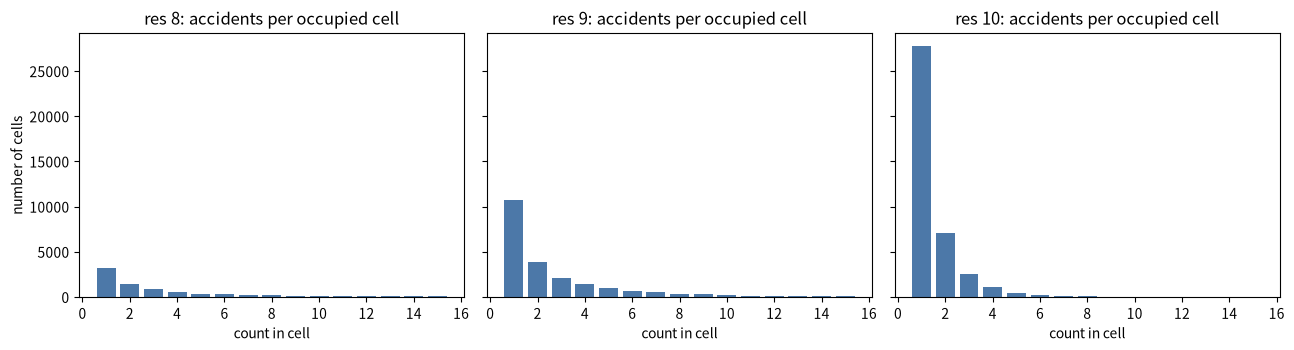

In [2]:
RES = [8, 9, 10]
agg = {}   # res -> DataFrame(cell, count, severity)
for r in RES:
    cells = [h3.latlng_to_cell(la, lo, r) for la, lo in zip(acc.lat, acc.lon)]
    g = (pd.DataFrame({"cell": cells, "severity": acc.severity.values})
         .groupby("cell").agg(count=("severity", "size"), severity=("severity", "sum")))
    agg[r] = g
    edge_m = h3.average_hexagon_edge_length(r, unit="m")
    n1 = int((g["count"] == 1).sum()); tot = len(g)
    print(f"res {r:>2}（邊長~{edge_m:5.0f}m）：占用格 {tot:>6,}｜=1 件 {n1:>6,} ({n1/tot:4.0%})｜"
          f"最大 {int(g['count'].max()):>4}｜中位 {int(g['count'].median())}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, r in zip(axes, RES):
    vc = agg[r]["count"].value_counts().sort_index()
    ax.bar(vc.index[:15], vc.values[:15], color="#4C78A8")
    ax.set_title(f"res {r}: accidents per occupied cell"); ax.set_xlabel("count in cell")
axes[0].set_ylabel("number of cells")
plt.tight_layout(); plt.show()

**判讀**：解析度越細，=1 件的格越多（36% → 49% → 70%），res-10 中位數已是 1
→ 接近「每格一件」，對鄰域統計太稀疏。先預期 **res-10 不宜當主力尺度**（下面 Moran / LISA 驗證）。

## 2. 全域 Moran's I

由 H3 鄰接（`grid_disk` k=1，只連占用格）建空間權重 W → Moran's I 問「鄰近格的事故數是否相似」。

**虛無假說 H0**：事故值在各 cell 上**空間隨機**（值與位置無關 = 把值隨機重排）；H1：存在空間自相關。

**permutation test 在做什麼**（`permutations=999`）：把「哪些格相鄰」固定不動，但把事故值在格之間**隨機洗牌** 999 次，
每次算一個 I → 這 999 個就是「純隨機會長怎樣」的參考分布。`p_sim = (洗牌中 I ≥ 觀測 + 1) / (999 + 1)`；
觀測比所有隨機都大 → `p_sim = 1/1000 = 0.001`（999 次能給的最小值）。用 999（配 +1 = 1000）是慣例，
要更細的 p（到 0.0001）就用 9999、代價是較慢。這是**不需常態假設**的檢定（直接跟真的隨機重排比）。

**「顯著」≠「重要」**：這裡有上萬個 cell，n 極大 → 只要有一點自相關 p 幾乎必然 <0.05。
**重點看效應量 = Moran's I 的數值**（res8 vs res10 的落差），不是 p。

**孤島格**（沒有占用鄰居）**不會被排除**，libpysal 保留為**零空間滯後**（僅警告），並在下表回報；
res 越細孤島越多 → 稀疏的徵兆，也會稀釋 Moran's I。

In [3]:
def build_w(cells, k=1):
    cset = set(cells)
    nb = {c: [n for n in h3.grid_disk(c, k) if n != c and n in cset] for c in cells}
    islands = [c for c, v in nb.items() if not v]
    w = W(nb, silence_warnings=True)
    return w, islands

def moran_on(r, col="count", k=1):
    g = agg[r]
    w, islands = build_w(list(g.index), k=k)
    y = g.loc[list(w.id_order), col].values.astype(float)
    mi = Moran(y, w, permutations=999)
    return mi, len(islands), w

print(f"{'res':>3} | {'Moran I':>8} | {'p_sim':>6} | {'孤島格':>7} | 占用格")
for r in RES:
    mi, nis, w = moran_on(r, "count")
    print(f"{r:>3} | {mi.I:>8.3f} | {mi.p_sim:>6.3f} | {nis:>7,} | {w.n:,}")

res |  Moran I |  p_sim |     孤島格 | 占用格
  8 |    0.635 |  0.001 |     660 | 8,863


  9 |    0.394 |  0.001 |   3,254 | 21,861


 10 |    0.089 |  0.001 |  11,420 | 39,545


**判讀**：Moran's I 隨解析度變細而下降（0.635 → 0.394 → 0.089）、孤島格暴增（660 → 3,254 → 11,420）
→ res-10 把聚集訊號稀釋掉（呼應 §1 的稀疏）。res-8/9 訊號清楚。（重點看 I 的**數值**，不是 p——n 大 p 必顯著。）

## 3. LISA（Local Moran's I）局部熱點

把每格分成 HH（高被高圍=熱點）/ LL / HL / LH（空間離群）。

**H0（每格，conditional permutation）**：固定該格、把其他值在鄰居間隨機重排也能產生此高低組合；
顯著 HH = 該格高且鄰居也高，超過隨機。

畫顯著格的中心點：**HH 紅**=事故熱點。比較 res 9（主力）與 res 10（對照）——若 res-10 太稀疏，
熱點會被打散/變少（真熱點的鄰居多是 0 → 被判 HL 而非 HH）。

> **探索性**：LISA 對上萬個 cell 各做一次 local test，有 multiple comparisons 問題；此處 `p<0.05`
> **未做多重檢定校正** → 熱點圖用於**發現與說明**，不作為嚴格因果或政策判定。

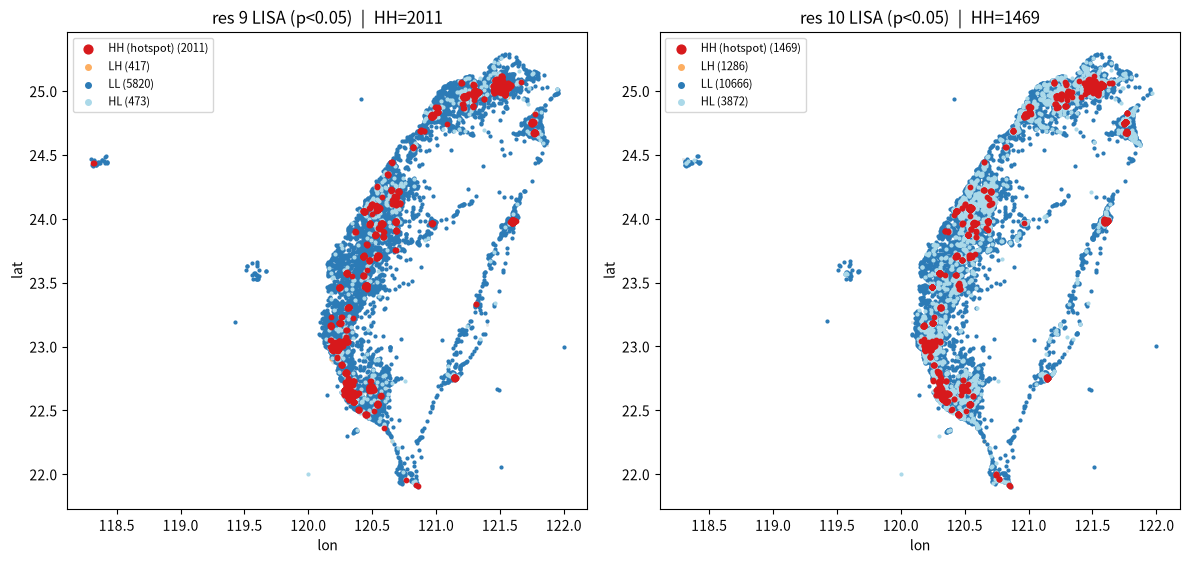

In [4]:
def lisa_points(r, col="count"):
    g = agg[r]
    w, _ = build_w(list(g.index), k=1)
    ids = list(w.id_order)
    y = g.loc[ids, col].values.astype(float)
    lm = Moran_Local(y, w, permutations=999, seed=42)
    sig = lm.p_sim < 0.05
    latlng = np.array([h3.cell_to_latlng(c) for c in ids])  # (lat, lon)
    return latlng, lm.q, sig

CLS = {1: ("HH (hotspot)", "#d7191c"), 2: ("LH", "#fdae61"),
       3: ("LL", "#2c7bb6"), 4: ("HL", "#abd9e9")}
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
for ax, r in zip(axes, [9, 10]):
    latlng, q, sig = lisa_points(r)
    ax.scatter(latlng[~sig, 1], latlng[~sig, 0], s=1, color="#e5e5e5", zorder=1)
    hh = 0
    for cls, (label, color) in CLS.items():
        m = sig & (q == cls)
        if m.any():
            ax.scatter(latlng[m, 1], latlng[m, 0], s=(10 if cls == 1 else 4),
                       color=color, label=f"{label} ({int(m.sum())})", zorder=3 if cls == 1 else 2)
        if cls == 1: hh = int(m.sum())
    ax.set_title(f"res {r} LISA (p<0.05)  |  HH={hh}"); ax.set_aspect("equal")
    ax.set_xlabel("lon"); ax.set_ylabel("lat"); ax.legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()

**決策：主力採 res 9**。
- **res-8**：I 最強、聚集清楚，但格大 → 熱點**定位較粗**。
- **res-9**：仍有明顯 I、LISA 熱點可辨識，尺度接近**城市道路** → 最適合看事故聚集。
- **res-10**：格太細、多數格 1 件、孤島多、LISA **破碎** → 不宜當主要 hotspot 尺度。

→ **res 9 主力**；res-8 留作更粗尺度對照、res-10 留作稀疏 / MAUP 對照。

## 4. Incremental Spatial Autocorrelation（找聚集尺度）

掃鄰居圈數 k（約當距離 ≈ k × 平均邊長），看 **Moran's I 隨鄰域半徑的變化**：
若出現**隆起（hump）**代表有某個「特徵尺度」；若**單調衰減**則代表聚集純粹是局部（最近鄰最強）。
這可**經驗地**決定分析尺度，也可作為未來 heatmap（若使用）的 bandwidth 依據。以 res 9 count 為例。
（用 Moran's I 而非 z-score：解析 z 會被鄰居數目膨脹、permutation z 在稀疏格會除零，兩者都不宜當尺度指標。）

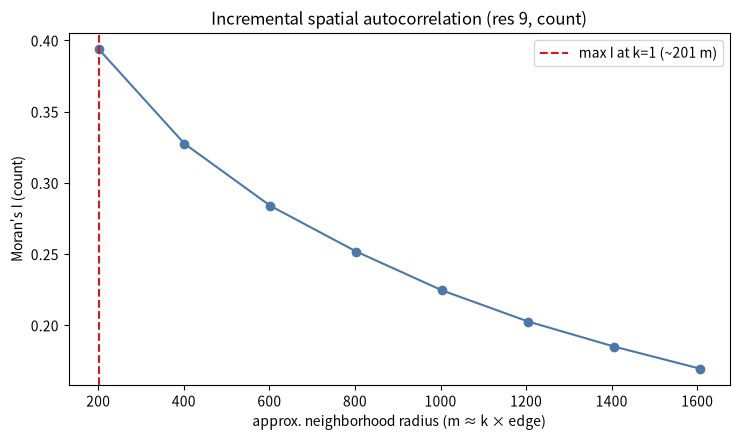

各 k 的 Moran I: [np.float64(0.394), np.float64(0.327), np.float64(0.284), np.float64(0.252), np.float64(0.224), np.float64(0.203), np.float64(0.185), np.float64(0.17)]
→ I 單調衰減、最高在最近鄰(k=1, ~201m) → 聚集是局部的，無更大特徵尺度(無 hump)


In [5]:
r = 9
edge = h3.average_hexagon_edge_length(r, unit="m")
ks = list(range(1, 9))
Is = [moran_on(r, "count", k=k)[0].I for k in ks]
peak = ks[int(np.argmax(Is))]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot([k*edge for k in ks], Is, "o-", color="#4C78A8")
ax.axvline(peak*edge, color="#d7191c", ls="--", label=f"max I at k={peak} (~{peak*edge:.0f} m)")
ax.set_xlabel("approx. neighborhood radius (m ≈ k × edge)"); ax.set_ylabel("Moran's I (count)")
ax.set_title(f"Incremental spatial autocorrelation (res {r}, count)"); ax.legend()
plt.tight_layout(); plt.show()
print("各 k 的 Moran I:", [round(i, 3) for i in Is])
print("→ I 單調衰減、最高在最近鄰(k=1, ~%.0fm) → 聚集是局部的，無更大特徵尺度(無 hump)" % edge)

**判讀**：Moran's I 隨鄰域半徑**單調衰減、無 hump** → 事故聚集是**局部尺度**（最近鄰最強），
沒有更大的特徵尺度。這也支持 hotspot 用較細（但別太細）的 res 9。

## 5. 結論 / 接續

- **稀疏驗證**：見 §1 的占用格分佈——res-10 多數格僅 1 件時，§3 的 res-10 LISA 熱點會比 res-9 稀疏/破碎，
  印證「太細 → 真熱點被打散、LISA 不穩」。主力用 res 8/9。
- **熱點**：§3 的 HH 標出事故顯著聚集區（探索性，未做多重檢定校正）；**聚集尺度**由 §4 的 Moran's I 曲線判讀（目前 k=1 最強後單調衰減 → 局部尺度、無更大特徵尺度峰值）。
- **顯著性判讀**：n 有上萬 cell，p 幾乎必然顯著 → 看 Moran's I 的**數值(效應量)**而非 p。
- **不做 road_risk「驗證」**：`road_risk` 由同一批事故導出 → 與事故熱點**非獨立**，吻合近乎必然、不算驗證。
  真正的預測性驗證應走**時間留出**（前幾年建、後幾年檢）。
- **caveat**：暴露量缺失（熱點≠人均風險）、MAUP（跨解析度看穩定性）、事故數零膨脹會壓低全域 Moran。

**接續**：時段/年份、A1/A2 分開的熱點；時間留出檢驗；聚集尺度可供未來 heatmap 的 bandwidth 參考。